# Geo Classifier 🏞️

## Problem 🤔

Classify images of natural scenes into 6 categories: Buildings, Forests, Glaciers, Mountains, Seas, or Streets.

## Data 📊

[Intel Image Classification Dataset from Kaggle](https://www.kaggle.com/datasets/puneet6060/intel-image-classification/data)

## Target 🎯

This is a fun project... So, for the first version let's try to achieve an accuracy of 65%!

## Features ✨

**id** -> image id of the geographic location

**geo_cat** -> category of the geographic scene out of the 6: buildings, forests, glaciers, moutains, seas or streets

## Workspace Setup 🛠️

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os
import kagglehub

In [4]:
# set matplotlib styling
plt.style.use("ggplot")

In [5]:
# drive.mount('/content/drive')

In [6]:
os.environ["KAGGLEHUB_CACHE"] = "/content/drive/MyDrive/kaggle_datasets"

path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

Path to dataset files: /content/drive/MyDrive/kaggle_datasets/datasets/puneet6060/intel-image-classification/versions/2


In [7]:
# @title Data Related Global Vars 🌐
BATCH_SIZE = 32
IMAGE_SIZE = (150, 150)

In [8]:
# train datase
train_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_train/seg_train", labels="inferred", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode="categorical")

# test and validation datasets
test_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_test/seg_test", labels="inferred", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode="categorical", validation_split=0.2, subset="training", seed=42)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_test/seg_test", labels="inferred", image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode="categorical", validation_split=0.2, subset="validation", seed=42)

# pred dataset
preds_ds = tf.keras.preprocessing.image_dataset_from_directory(f"{path}/seg_pred/seg_pred", labels=None, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.
Using 2400 files for training.
Found 3000 files belonging to 6 classes.
Using 600 files for validation.
Found 7301 files.


In [9]:
train_ds.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 6), dtype=tf.float32, name=None))>

In [10]:
train_ds.element_spec

(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 6), dtype=tf.float32, name=None))

## EDA 🔎

In [11]:
class_names = train_ds.class_names
print("Classes:", class_names)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [12]:
# from collections import Counter

# counts = Counter([])
# for _, labels in train_ds:
#     for label in labels:
#         counts.update(np.where(label.numpy() == 1)[0].tolist())

# class_distributions = {class_names[i]: value for i, value in dict(counts).items()}
# print("Class distribution:", class_distributions)

class_distributions = {'buildings': 2191, 'glacier': 2404, 'forest': 2271, 'street': 2382, 'mountain': 2512, 'sea': 2274}

print(f"Class distribution: {class_distributions}")

Class distribution: {'buildings': 2191, 'glacier': 2404, 'forest': 2271, 'street': 2382, 'mountain': 2512, 'sea': 2274}


In [13]:
class_distribution_df = pd.DataFrame(list(class_distributions.items()), columns=['Class', 'Count'])
class_distribution_df

,Class,Count
0,buildings,2191
1,glacier,2404
2,forest,2271
3,street,2382
4,mountain,2512
5,sea,2274


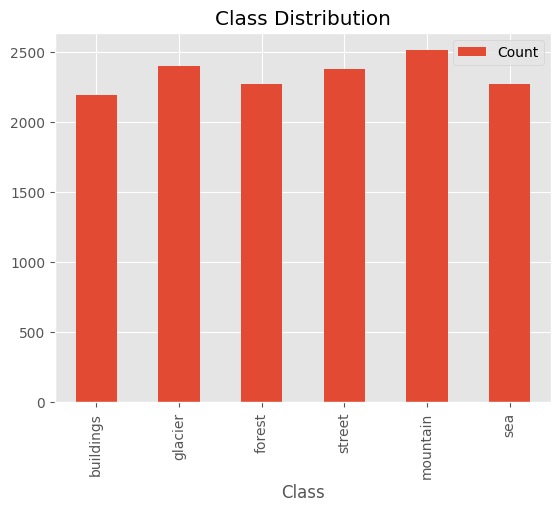

In [14]:
class_distribution_df.plot(kind='bar', x='Class', y='Count', title='Class Distribution')
plt.show()

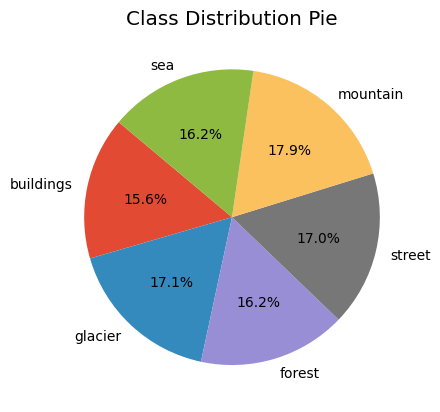

In [15]:
plt.pie(class_distributions.values(), labels=class_distributions.keys(), autopct="%1.1f%%", startangle=140)
plt.title("Class Distribution Pie")
plt.show()

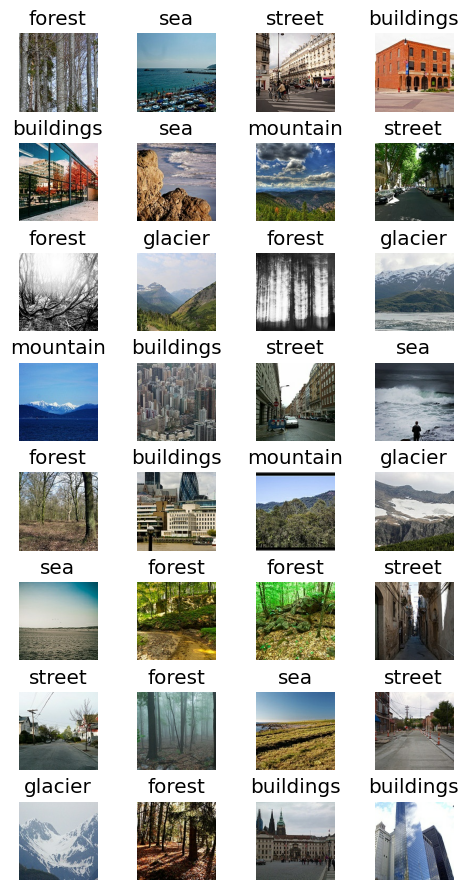

In [16]:
plt.figure(figsize=(5, 9))
for images, labels in train_ds.take(1):  # take one batch
    for i in range(BATCH_SIZE):  # show first 9 images
        plt.subplot(8, 4, i + 1)

        plt.grid(False)
        plt.xticks([])
        plt.yticks([])
        plt.axis("off")

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.where(labels[i] == 1)[0][0]])
    break

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)
plt.show()

In [17]:
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)

Image shape: (32, 150, 150, 3)
Label shape: (32, 6)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'float32'>


## Data Preprocessing ⚙️

In [18]:
augmentation_model = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(factor=0.15),  # randomly rotate images (factor is a fraction of pi radians)
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1),  # randomly zoom images
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # flips the image
])

augmented_train_ds = train_ds.map(lambda x, y: (augmentation_model(x, training=True), y))

## Modelling Global Vars 🌐

In [24]:
INPUT_SHAPE = [150, 150, 3]
OUTPUT_SHAPE = len(class_distributions.keys())
N_EPOCHS = 128

MODEL_SAVE_PATH = "/content/drive/MyDrive/trained_models/geo_classifier/"

## Basic CNN Modelling 💡

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling, Input

def build_and_compile_vanilla_cnn():
    model = Sequential()

    model.add(Input(INPUT_SHAPE))
    model.add(Rescaling(1./255))

    model.add(Conv2D(32, (3, 3), activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Conv2D(32, (3, 3), activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    model.add(Flatten())

    model.add(Dense(128, activation="relu"))

    model.add(Dense(OUTPUT_SHAPE, activation="softmax"))

    model.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.CategoricalCrossentropy(), metrics=["accuracy"])

    return model

In [ ]:
def get_model_checkpoint_callback(model_name):
    return tf.keras.callbacks.ModelCheckpoint(
        filepath=f"/content/drive/MyDrive/google_colab_model_checkpoints/geo_classifier/{model_name}.weights.h5",
        save_weights_only=True,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True
    )

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3)

In [ ]:
vanilla_cnn_model = build_and_compile_vanilla_cnn()

history = vanilla_cnn_model.fit(
    augmented_train_ds,
    epochs=N_EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping, get_model_checkpoint_callback("vanilla_cnn")]
)

Epoch 1/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 89s 187ms/step - accuracy: 0.3901 - loss: 3.0114 - val_accuracy: 0.3950 - val_loss: 6.1552
Epoch 2/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 133s 176ms/step - accuracy: 0.5268 - loss: 1.1907 - val_accuracy: 0.5850 - val_loss: 1.0698
Epoch 3/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 82s 176ms/step - accuracy: 0.5572 - loss: 1.0871 - val_accuracy: 0.5183 - val_loss: 1.3065
Epoch 4/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 82s 176ms/step - accuracy: 0.5634 - loss: 1.0833 - val_accuracy: 0.5833 - val_loss: 1.1032
Epoch 5/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 83s 177ms/step - accuracy: 0.6075 - loss: 1.0061 - val_accuracy: 0.6033 - val_loss: 1.1407
Epoch 6/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 77s 175ms/step - accuracy: 0.6282 - loss: 0.9673 - val_accuracy: 0.5783 - val_loss: 1.2075
Epoch 7/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 78s 178ms/step - accuracy: 0.6464 - loss: 0.9143 - val_accuracy: 0.6000 - val_loss: 1.1630
Epoch 8/128
439/439 ━━━━━━━━━━━━━━━━━━━━ 77s 174ms/step - accuracy: 0.6598 

In [ ]:
vanilla_cnn_model.evaluate(test_ds)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5640 - loss: 1.4472


[1.4778327941894531, 0.5600000023841858]

In [ ]:
vanilla_cnn_model.save(MODEL_SAVE_PATH + "vanilla_cnn_model.keras")

In [ ]:
y_pred_probs = vanilla_cnn_model.predict(test_ds)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [ ]:
y_pred = np.argmax(y_pred_probs, axis=1)
y_pred

array([4, 4, 5, ..., 5, 4, 4])

In [ ]:
def visualize_history_metric(his_obj, metric):
    """
        Plots how a specific metric changes with each epoch.
    """
    plt.plot(history.history[metric], "bo--", label=metric)
    plt.plot(history.history["val_"+metric], "ro--", label="val_"+metric)

    plt.title(f"{metric} vs val_{metric}")
    plt.xlabel("epochs")
    plt.ylabel(metric)
    plt.legend()

#### Training History 📈

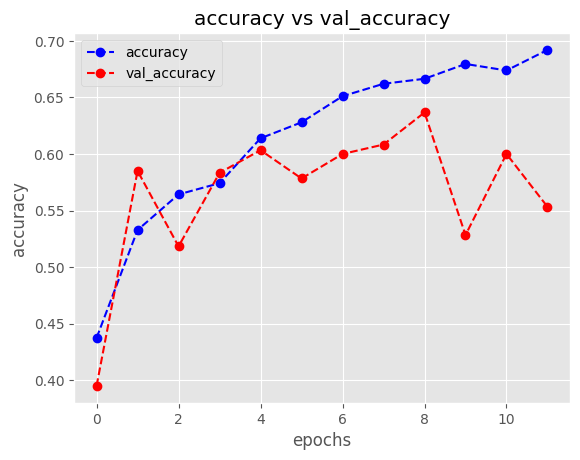

In [ ]:
visualize_history_metric(history, "accuracy")

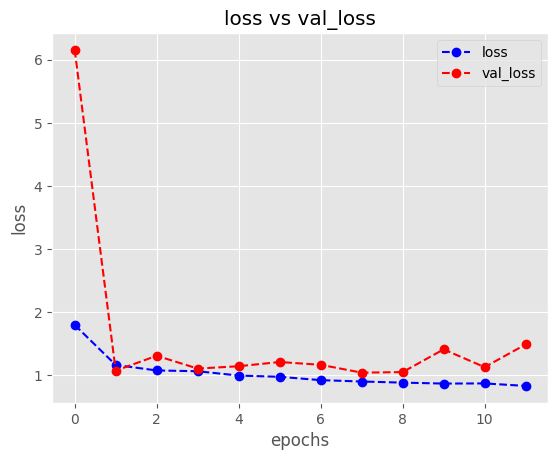

In [ ]:
visualize_history_metric(history, "loss")

### Error Analysis ⚠️

In [ ]:
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_true_labels = np.argmax(y_true, axis=1)

In [ ]:
conf_matrix = tf.math.confusion_matrix(y_true_labels, y_pred)

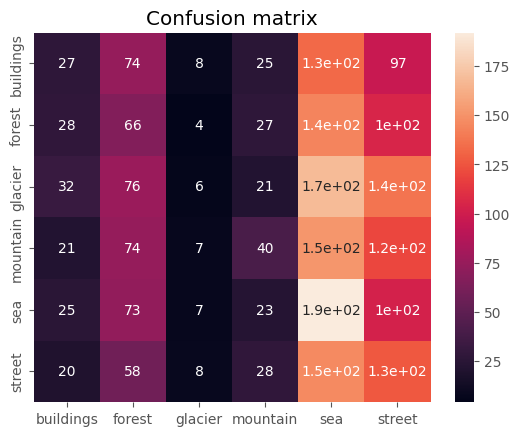

In [ ]:
ax = plt.axes()
sns.heatmap(conf_matrix, annot=True,
           annot_kws={"size": 10},
           xticklabels=class_names,
           yticklabels=class_names, ax = ax)
ax.set_title('Confusion matrix')
plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
import tensorflow as tf

def analyze_model_performance(model, test_ds, class_names):
    """
    Comprehensive analysis of model performance including confusion matrix,
    per-class metrics, and misclassified examples visualization.
    """
    # Get predictions and true labels
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    y_true = np.concatenate([y.numpy() for _, y in test_ds])
    y_true_labels = np.argmax(y_true, axis=1)

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))

    # 1. Confusion Matrix
    ax1 = plt.subplot(2, 2, 1)
    conf_matrix = tf.math.confusion_matrix(y_true_labels, y_pred)
    conf_matrix_norm = conf_matrix.numpy().astype('float') / conf_matrix.numpy().sum(axis=1)[:, np.newaxis]

    sns.heatmap(conf_matrix_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title('Normalized Confusion Matrix')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')

    # 2. Per-class Accuracy
    ax2 = plt.subplot(2, 2, 2)
    class_accuracies = conf_matrix_norm.diagonal()
    bars = ax2.bar(class_names, class_accuracies)
    ax2.set_title('Per-class Accuracy')
    ax2.set_xlabel('Class')
    ax2.set_ylabel('Accuracy')
    plt.xticks(rotation=45)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom')

    # 3. Confidence Distribution
    ax3 = plt.subplot(2, 2, 3)
    correct_conf = y_pred_probs[y_pred == y_true_labels].max(axis=1)
    incorrect_conf = y_pred_probs[y_pred != y_true_labels].max(axis=1)

    sns.histplot(data=correct_conf, label='Correct Predictions',
                alpha=0.5, color='green', ax=ax3)
    sns.histplot(data=incorrect_conf, label='Incorrect Predictions',
                alpha=0.5, color='red', ax=ax3)
    ax3.set_title('Prediction Confidence Distribution')
    ax3.set_xlabel('Confidence')
    ax3.set_ylabel('Count')
    ax3.legend()

    # 4. Most Confused Pairs
    ax4 = plt.subplot(2, 2, 4)
    conf_matrix_without_diag = conf_matrix.numpy()
    np.fill_diagonal(conf_matrix_without_diag, 0)
    most_confused = []

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j:
                most_confused.append((class_names[i], class_names[j],
                                    conf_matrix_without_diag[i, j]))

    most_confused.sort(key=lambda x: x[2], reverse=True)
    top_confused = most_confused[:5]

    pairs = [f"{true}\n→{pred}" for true, pred, _ in top_confused]
    values = [count for _, _, count in top_confused]

    bars = ax4.bar(pairs, values)
    ax4.set_title('Top 5 Most Confused Class Pairs')
    ax4.set_xlabel('True → Predicted')
    ax4.set_ylabel('Count')
    plt.xticks(rotation=45)

    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true_labels, y_pred, target_names=class_names))

    return {
        'confusion_matrix': conf_matrix,
        'class_accuracies': class_accuracies,
        'correct_confidences': correct_conf,
        'incorrect_confidences': incorrect_conf,
        'most_confused_pairs': most_confused
    }

In [ ]:
analysis_results = analyze_model_performance(vanilla_cnn_model, test_ds, class_names)

## ResNet Modelling 🥅

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Flatten, Dense, Dropout, BatchNormalization, Rescaling, Input

def build_resnet(input_shape=(150, 150, 3), num_classes=6):
    base_model = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_shape=input_shape)
    base_model.trainable = False  # Freeze the base model

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation="relu"),
        Dropout(0.2),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss=tf.keras.losses.CategoricalCrossentropy(), metrics=["accuracy"])

    return model

resnet_model = build_resnet()
resnet_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 5, 5, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │           1,542 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = resnet_model.fit(
    augmented_train_ds,
    epochs=12,
    validation_data=val_ds,
    callbacks=[early_stopping, get_model_checkpoint_callback("resnet_model")]
)

Epoch 1/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 1851s 4s/step - accuracy: 0.6800 - loss: 0.8430 - val_accuracy: 0.8550 - val_loss: 0.3954
Epoch 2/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 142s 240ms/step - accuracy: 0.8456 - loss: 0.4321 - val_accuracy: 0.8783 - val_loss: 0.3440
Epoch 3/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 108s 245ms/step - accuracy: 0.8525 - loss: 0.3947 - val_accuracy: 0.8900 - val_loss: 0.3362
Epoch 4/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 105s 239ms/step - accuracy: 0.8675 - loss: 0.3615 - val_accuracy: 0.8950 - val_loss: 0.3202
Epoch 5/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 139s 232ms/step - accuracy: 0.8829 - loss: 0.3305 - val_accuracy: 0.9000 - val_loss: 0.3069
Epoch 6/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 140s 228ms/step - accuracy: 0.8838 - loss: 0.3155 - val_accuracy: 0.8917 - val_loss: 0.3167
Epoch 7/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 142s 228ms/step - accuracy: 0.8904 - loss: 0.3141 - val_accuracy: 0.8933 - val_loss: 0.3091
Epoch 8/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 102s 233ms/step - accuracy: 0.8951 - l

In [ ]:
resnet_model.evaluate(test_ds)

75/75 ━━━━━━━━━━━━━━━━━━━━ 638s 9s/step - accuracy: 0.8988 - loss: 0.2899


[0.2973707616329193, 0.8924999833106995]

In [ ]:
resnet_model.save(MODEL_SAVE_PATH + "resnet_model.keras")

### Error Analysis ⚠️

75/75 ━━━━━━━━━━━━━━━━━━━━ 802s 11s/step


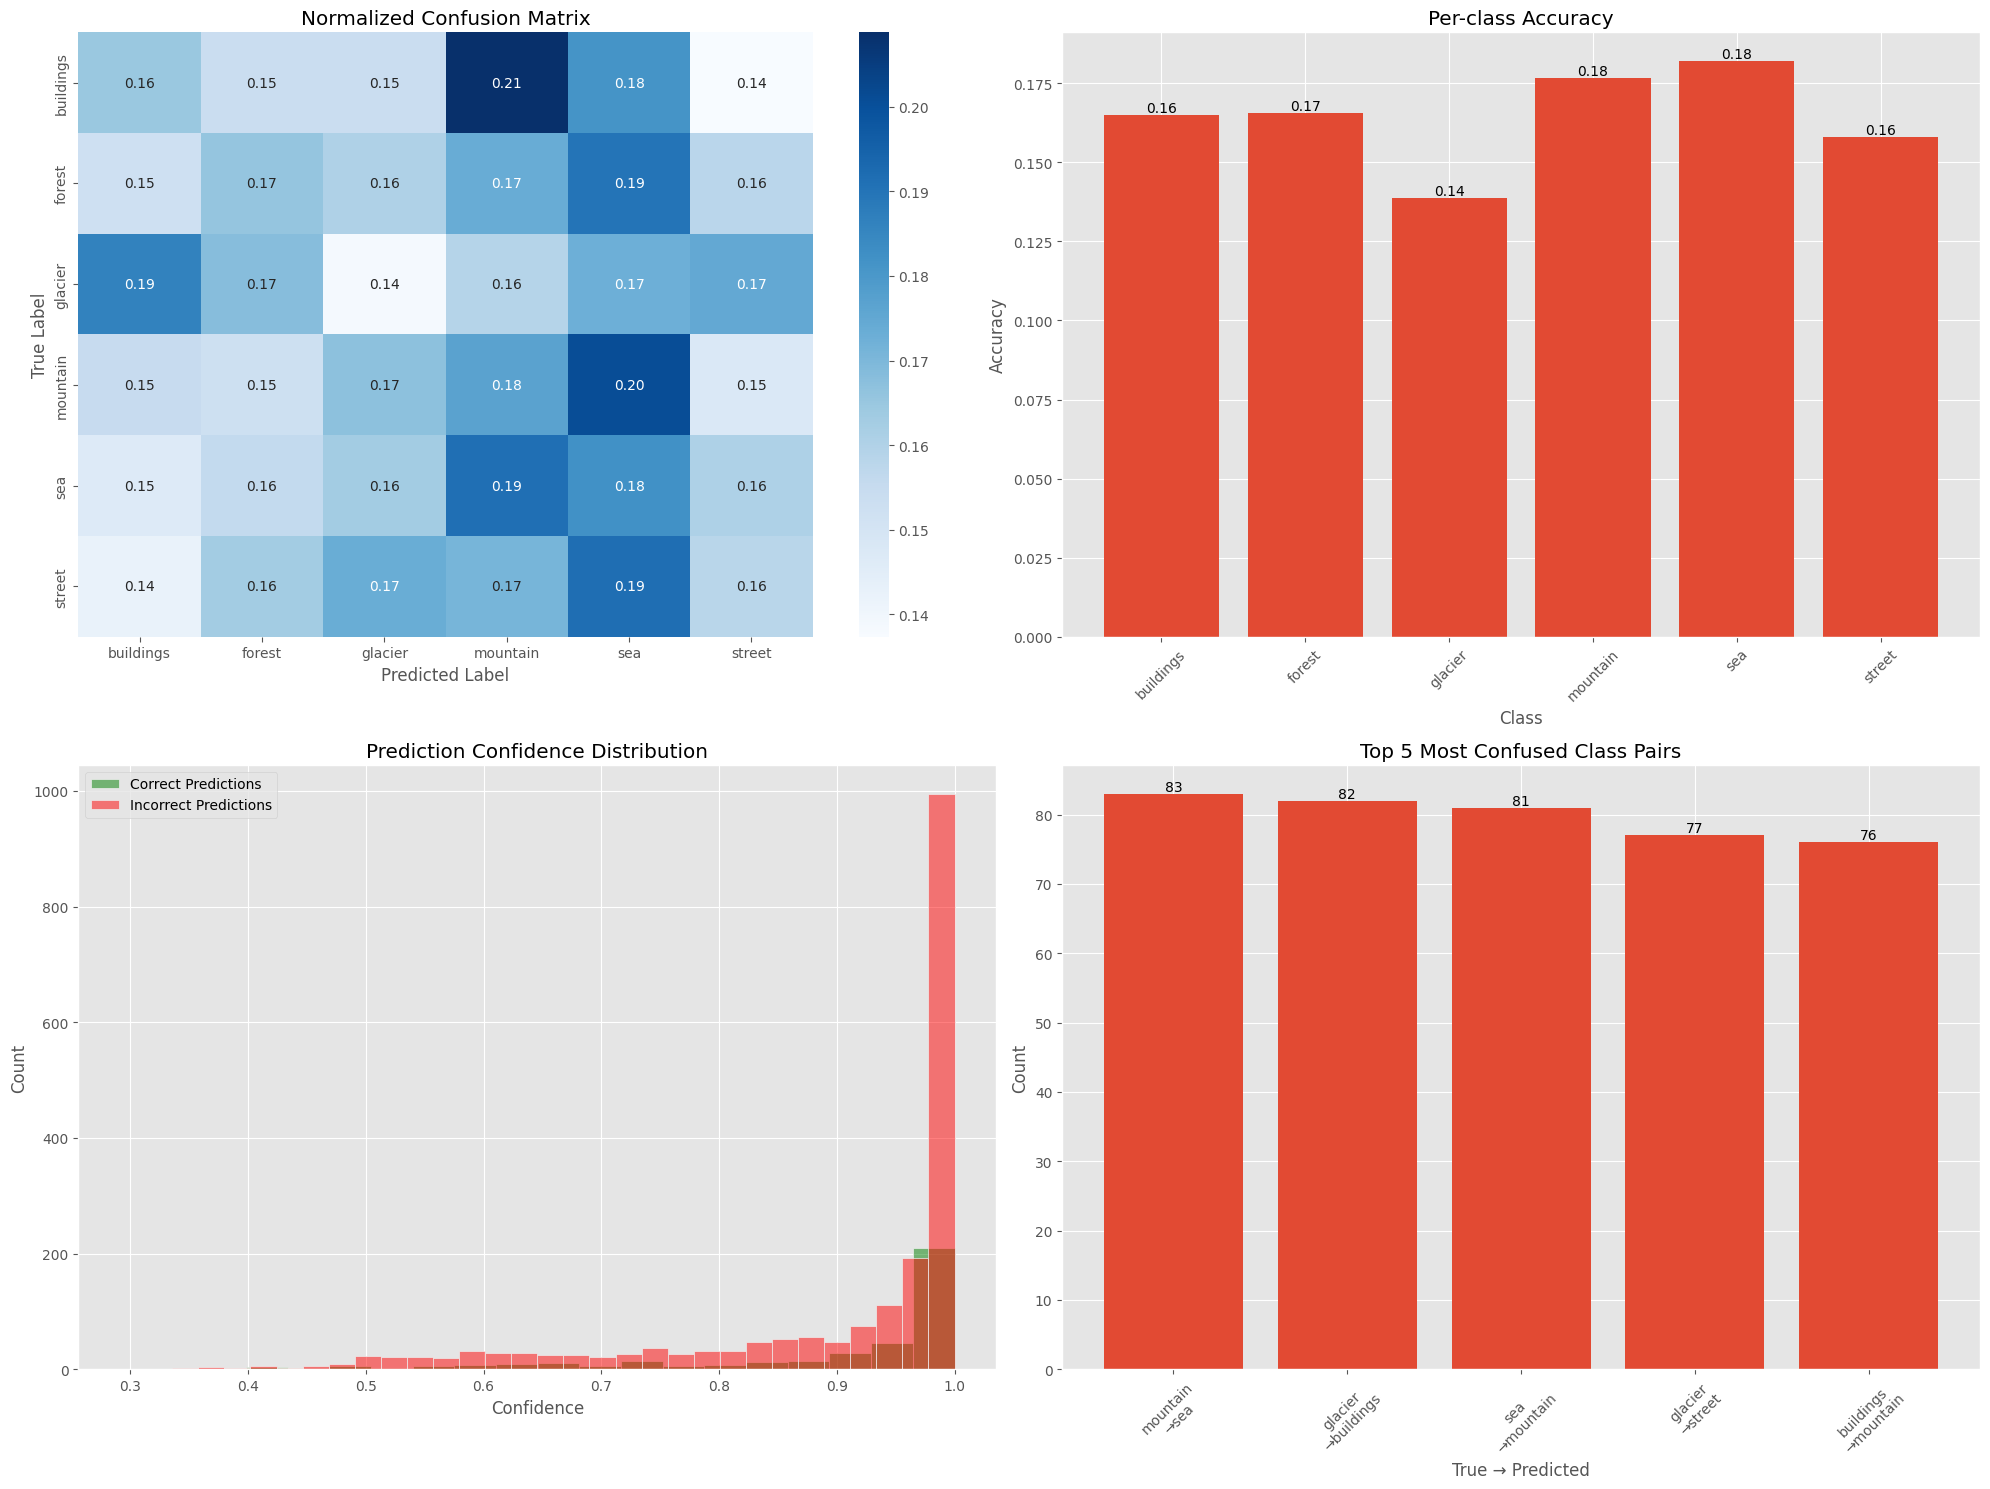


Classification Report:
              precision    recall  f1-score   support

   buildings       0.16      0.16      0.16       364
      forest       0.16      0.17      0.16       374
     glacier       0.16      0.14      0.15       440
    mountain       0.17      0.18      0.17       413
         sea       0.17      0.18      0.18       423
      street       0.16      0.16      0.16       386

    accuracy                           0.16      2400
   macro avg       0.16      0.16      0.16      2400
weighted avg       0.16      0.16      0.16      2400



{'confusion_matrix': <tf.Tensor: shape=(6, 6), dtype=int32, numpy=
 array([[60, 56, 56, 76, 66, 50],
        [57, 62, 60, 65, 71, 59],
        [82, 74, 61, 70, 76, 77],
        [64, 63, 69, 73, 83, 61],
        [62, 66, 69, 81, 77, 68],
        [55, 63, 67, 66, 74, 61]], dtype=int32)>,
 'class_accuracies': array([0.16483516, 0.1657754 , 0.13863636, 0.17675545, 0.1820331 ,
        0.15803109]),
 'correct_confidences': array([0.95249444, 0.9997577 , 0.9984969 , 0.9831187 , 0.9863521 ,
        0.9999509 , 0.9996315 , 0.9749562 , 0.75987595, 0.74778694,
        0.8558739 , 0.53897274, 0.89241004, 0.9998658 , 0.7323433 ,
        0.9998253 , 0.98529875, 0.9896236 , 0.40602154, 0.99999785,
        0.99999154, 0.95801586, 0.9997665 , 0.99999106, 0.6863415 ,
        0.99755186, 0.95455736, 0.93076   , 0.9945627 , 0.997071  ,
        0.85964316, 0.67566586, 0.60821563, 0.9676867 , 0.999645  ,
        0.99623674, 0.8685814 , 0.9993293 , 0.9467229 , 0.6292141 ,
        0.9968407 , 0.8264887 , 0.72

In [28]:
analyze_model_performance(resnet_model, test_ds, class_names)

## CNN Model Ensemble 🤝